# NexusTrader Experiments — Persistent Scoring & Analysis Notebook

This notebook is redesigned for **reusable, persistent evaluation**.

What it guarantees each run:
1. Load raw JSONL agent outputs
2. Score every row consistently
3. Upsert scored rows into long-lived registries
4. Save timestamped analysis bundles (CSV + JSON + charts)
5. Keep comparisons reproducible across run tags

Use this as the single source of truth for experiment reporting.

In [260]:
from __future__ import annotations

import json
import random
from datetime import datetime, timedelta
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background")
pd.set_option("display.max_columns", 200)

## 1) Global Configuration

In [261]:
ROOT = Path(r"c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments")
RAW_DIR = ROOT / "results" / "raw"
SCORED_DIR = ROOT / "results" / "scored"
CHART_DIR = ROOT / "results" / "charts"
REPORT_DIR = ROOT / "results" / "analysis_reports"

SCORED_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON_MAP = {"short": 10, "medium": 21, "long": 126}
HOLD_EPSILON = 0.025
RANDOM_SEED = 42

# Analyze both Stage A v8 and Stage B v1 files
AGENT_RUN_GLOB = "batch_stageB_hurtset_debug_20260309_223348.jsonl"

# Baseline controls
ENABLE_BASELINES = True

print("RAW_DIR:", RAW_DIR)
print("Matched agent JSONL files:", len(list(RAW_DIR.glob(AGENT_RUN_GLOB))))

RAW_DIR: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\raw
Matched agent JSONL files: 1


## 2) Core Helpers (Price Fetch, Scoring, Parsing)

In [262]:
import re
import yfinance as yf

@lru_cache(maxsize=4096)
def get_close_series(ticker: str, start_iso: str, end_iso: str):
    hist = yf.Ticker(ticker).history(start=start_iso, end=end_iso, auto_adjust=True)
    if hist.empty:
        return None
    s = hist["Close"].dropna()
    return s

def k_return(ticker: str, as_of: str, k: int):
    t0 = datetime.fromisoformat(as_of)
    t1 = t0 + timedelta(days=max(14, 4 * k))
    s = get_close_series(ticker, t0.date().isoformat(), t1.date().isoformat())
    if s is None or len(s) <= k:
        return np.nan
    p0 = float(s.iloc[0])
    pk = float(s.iloc[k])
    if p0 == 0:
        return np.nan
    return (pk - p0) / p0

def directional_correct(action: str, ret: float, hold_epsilon: float = HOLD_EPSILON):
    if pd.isna(ret):
        return np.nan
    a = (action or "HOLD").upper()
    if a == "BUY":
        return 1 if ret > 0 else 0
    if a == "SELL":
        return 1 if ret < 0 else 0
    if a == "HOLD":
        return 1 if abs(ret) < hold_epsilon else 0
    return np.nan

def true_direction_label(ret: float, hold_epsilon: float = HOLD_EPSILON):
    if pd.isna(ret):
        return np.nan
    if abs(ret) < hold_epsilon:
        return "HOLD"
    return "BUY" if ret > 0 else "SELL"

def extract_agent_action(obj: dict):
    result = obj.get("result", {}) if isinstance(obj, dict) else {}
    ts = result.get("trading_strategy", {}) if isinstance(result, dict) else {}
    return (ts.get("action") or "HOLD").upper()

def extract_confidence_band(obj: dict):
    result = obj.get("result", {}) if isinstance(obj, dict) else {}
    ts = result.get("trading_strategy", {}) if isinstance(result, dict) else {}
    rationale = (ts.get("rationale") or "")
    m = re.search(r"CONFIDENCE\s*[=:]\s*(LOW|MEDIUM|HIGH)", rationale, re.IGNORECASE)
    if m:
        return m.group(1).upper()
    m2 = re.search(r"confidence\s*band\s*[:=]\s*(LOW|MEDIUM|HIGH)", rationale, re.IGNORECASE)
    if m2:
        return m2.group(1).upper()
    return "UNKNOWN"

def parse_tag_and_timestamp(filename: str):
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) < 4:
        return stem, "unknown"
    ts = "_".join(parts[-2:])
    tag = "_".join(parts[1:-2])
    return tag, ts

## 3) Load Agent JSONL and Persist Scored Registry

In [263]:
def load_agent_runs(raw_dir: Path, pattern: str):
    rows = []
    for p in sorted(raw_dir.glob(pattern)):
        run_tag, run_ts = parse_tag_and_timestamp(p.name)
        with p.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                if "error" in obj:
                    continue

                ticker = obj.get("ticker")
                simulated_date = obj.get("simulated_date")
                horizon = obj.get("horizon", "short")
                k = HORIZON_MAP.get(horizon, 10)
                action = extract_agent_action(obj)
                ret = k_return(ticker, simulated_date, k)

                rows.append({
                    "source": "agent",
                    "strategy": "nexustrader",
                    "run_file": p.name,
                    "run_tag": run_tag,
                    "run_timestamp": run_ts,
                    "ticker": ticker,
                    "simulated_date": simulated_date,
                    "horizon": horizon,
                    "k": int(k),
                    "action": action,
                    "k_return": ret,
                    "correct": directional_correct(action, ret),
                    "true_label": true_direction_label(ret),
                    "confidence_band": extract_confidence_band(obj),
                })

    return pd.DataFrame(rows)

AGENT_REGISTRY_PATH = SCORED_DIR / "agent_runs_scored_registry.csv"
incoming_agent_df = load_agent_runs(RAW_DIR, AGENT_RUN_GLOB)

if AGENT_REGISTRY_PATH.exists():
    agent_registry_df = pd.read_csv(AGENT_REGISTRY_PATH)
else:
    agent_registry_df = pd.DataFrame(columns=incoming_agent_df.columns)

if not incoming_agent_df.empty:
    agent_registry_df = pd.concat([agent_registry_df, incoming_agent_df], ignore_index=True)
    key_cols = ["run_file", "ticker", "simulated_date", "horizon", "k", "action"]
    agent_registry_df = agent_registry_df.drop_duplicates(subset=key_cols, keep="last").reset_index(drop=True)
    agent_registry_df.to_csv(AGENT_REGISTRY_PATH, index=False)

analysis_agent_df = incoming_agent_df.copy() if not incoming_agent_df.empty else agent_registry_df.copy()

print("Incoming rows:", len(incoming_agent_df))
print("Registry rows:", len(agent_registry_df))
print("Analysis rows:", len(analysis_agent_df))
print("Saved registry:", AGENT_REGISTRY_PATH)
display(analysis_agent_df.head(3))

Incoming rows: 60
Registry rows: 3225
Analysis rows: 60
Saved registry: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\scored\agent_runs_scored_registry.csv


,source,strategy,run_file,run_tag,run_timestamp,ticker,simulated_date,horizon,k,action,k_return,correct,true_label,confidence_band
0,agent,nexustrader,batch_stageB_hurtset_debug_20260309_223348.jsonl,stageB_hurtset_debug,20260309_223348,JPM,2025-04-07,short,10,SELL,0.098629,0,BUY,HIGH
1,agent,nexustrader,batch_stageB_hurtset_debug_20260309_223348.jsonl,stageB_hurtset_debug,20260309_223348,AAPL,2021-11-15,short,10,HOLD,0.102000,0,BUY,HIGH
2,agent,nexustrader,batch_stageB_hurtset_debug_20260309_223348.jsonl,stageB_hurtset_debug,20260309_223348,NVDA,2022-11-28,short,10,HOLD,0.108200,0,BUY,MEDIUM


## 4) Build Universe and Optional Baselines

In [264]:
if analysis_agent_df.empty:
    raise RuntimeError("No agent rows available. Check AGENT_RUN_GLOB and raw files.")

universe = (
    analysis_agent_df[["ticker", "simulated_date", "horizon", "k"]]
    .drop_duplicates()
    .sort_values(["ticker", "simulated_date", "horizon"])
    .reset_index(drop=True)
)

n_tickers = universe["ticker"].nunique()
n_dates = universe["simulated_date"].nunique()
print(f"Universe rows={len(universe)}, tickers={n_tickers}, dates={n_dates}, tickers*dates={n_tickers*n_dates}")
display(universe.head(10))

Universe rows=60, tickers=5, dates=40, tickers*dates=200


,ticker,simulated_date,horizon,k
0,AAPL,2021-11-15,short,10
1,AAPL,2022-01-17,short,10
2,AAPL,2022-05-23,short,10
3,AAPL,2022-10-17,short,10
4,AAPL,2022-11-28,short,10
5,AAPL,2023-03-13,short,10
6,AAPL,2023-04-24,short,10
7,AAPL,2023-06-26,short,10
8,AAPL,2023-10-30,short,10
9,AAPL,2024-09-09,short,10


## 5) Baseline Definitions and Baseline Registry

In [265]:
def baseline_buy_hold(_ticker: str, _date: str):
    return "BUY"

def baseline_sma(ticker: str, date: str, short_w: int = 20, long_w: int = 50):
    t = datetime.fromisoformat(date)
    s = get_close_series(ticker, (t - timedelta(days=3 * long_w)).date().isoformat(), t.date().isoformat())
    if s is None or len(s) < long_w:
        return "HOLD"
    sma_s = s.tail(short_w).mean()
    sma_l = s.tail(long_w).mean()
    if sma_s > 1.01 * sma_l:
        return "BUY"
    if sma_s < 0.99 * sma_l:
        return "SELL"
    return "HOLD"

def baseline_rsi(ticker: str, date: str, period: int = 14):
    t = datetime.fromisoformat(date)
    s = get_close_series(ticker, (t - timedelta(days=6 * period)).date().isoformat(), t.date().isoformat())
    if s is None or len(s) < period + 1:
        return "HOLD"
    d = s.diff().dropna()
    up = d.clip(lower=0).tail(period).mean()
    dn = (-d.clip(upper=0)).tail(period).mean()
    rs = up / (dn + 1e-9)
    rsi = 100 - (100 / (1 + rs))
    if rsi < 30:
        return "BUY"
    if rsi > 70:
        return "SELL"
    return "HOLD"

_rng = random.Random(RANDOM_SEED)
def baseline_random(_ticker: str, _date: str):
    return _rng.choice(["BUY", "SELL", "HOLD"])

## 6) Compute/Upsert Baselines (Optional)

In [266]:
baseline_specs = {
    "buy_hold": baseline_buy_hold,
    "sma_crossover": baseline_sma,
    "rsi_14": baseline_rsi,
    "random_uniform": baseline_random,
}

BASELINE_REGISTRY_PATH = SCORED_DIR / "baselines_registry.csv"
baseline_df = pd.DataFrame()

if ENABLE_BASELINES:
    if BASELINE_REGISTRY_PATH.exists():
        baseline_registry_df = pd.read_csv(BASELINE_REGISTRY_PATH)
    else:
        baseline_registry_df = pd.DataFrame(columns=[
            "source", "strategy", "run_file", "run_tag", "run_timestamp",
            "ticker", "simulated_date", "horizon", "k", "action", "k_return", "correct", "true_label", "confidence_band"
        ])

    needed = (
        universe.assign(_tmp=1)
        .merge(pd.DataFrame({"strategy": list(baseline_specs.keys()), "_tmp": 1}), on="_tmp")
        .drop(columns="_tmp")[["strategy", "ticker", "simulated_date", "horizon", "k"]]
        .reset_index(drop=True)
    )

    existing_keys = baseline_registry_df[["strategy", "ticker", "simulated_date", "horizon", "k"]].drop_duplicates() if not baseline_registry_df.empty else pd.DataFrame(columns=["strategy", "ticker", "simulated_date", "horizon", "k"])
    missing = needed.merge(existing_keys, on=["strategy", "ticker", "simulated_date", "horizon", "k"], how="left", indicator=True)
    missing = missing[missing["_merge"].eq("left_only")].drop(columns="_merge")

    new_rows = []
    for r in missing.itertuples(index=False):
        fn = baseline_specs[r.strategy]
        action = fn(r.ticker, r.simulated_date)
        ret = k_return(r.ticker, r.simulated_date, int(r.k))
        new_rows.append({
            "source": "baseline",
            "strategy": r.strategy,
            "run_file": "baseline_recomputed",
            "run_tag": "baseline",
            "run_timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
            "ticker": r.ticker,
            "simulated_date": r.simulated_date,
            "horizon": r.horizon,
            "k": int(r.k),
            "action": action,
            "k_return": ret,
            "correct": directional_correct(action, ret),
            "true_label": true_direction_label(ret),
            "confidence_band": "N/A",
        })

    new_baselines_df = pd.DataFrame(new_rows)
    baseline_registry_df = pd.concat([baseline_registry_df, new_baselines_df], ignore_index=True)
    baseline_registry_df = baseline_registry_df.drop_duplicates(subset=["strategy", "ticker", "simulated_date", "horizon", "k"], keep="last").reset_index(drop=True)
    baseline_registry_df.to_csv(BASELINE_REGISTRY_PATH, index=False)

    baseline_df = baseline_registry_df.merge(
        universe[["ticker", "simulated_date", "horizon", "k"]].drop_duplicates(),
        on=["ticker", "simulated_date", "horizon", "k"],
        how="inner"
    ).reset_index(drop=True)

    print("Baseline rows used:", len(baseline_df), "| New rows computed:", len(new_baselines_df))
    print("Saved registry:", BASELINE_REGISTRY_PATH)
else:
    print("Baselines disabled.")

Baseline rows used: 240 | New rows computed: 0
Saved registry: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\scored\baselines_registry.csv


## 7) Reusable Analysis Functions (Primary + Secondary Metrics)

In [267]:
def directional_accuracy_ex_hold(df: pd.DataFrame):
    d = df[df["action"].isin(["BUY", "SELL"])].copy()
    if d.empty:
        return np.nan, 0
    acc = d["correct"].mean() * 100
    return acc, len(d)

def hold_quality(df: pd.DataFrame, eps: float = HOLD_EPSILON):
    h = df[df["action"].eq("HOLD")].copy()
    if h.empty:
        return {"hold_n": 0, "hold_rate_%": 0.0, "hold_precision_%": np.nan, "hold_far_miss_n": 0}
    h["abs_ret"] = h["k_return"].abs()
    hold_precision = (h["abs_ret"] < eps).mean() * 100
    return {
        "hold_n": int(len(h)),
        "hold_rate_%": len(h) / max(len(df), 1) * 100,
        "hold_precision_%": hold_precision,
        "hold_far_miss_n": int((h["abs_ret"] >= eps).sum()),
    }

def strategy_return_series(df: pd.DataFrame):
    d = df.copy()
    d["strategy_return"] = np.where(
        d["action"].eq("BUY"), d["k_return"],
        np.where(d["action"].eq("SELL"), -d["k_return"], 0.0)
    )
    d["buy_hold_return"] = d["k_return"]
    d["excess_vs_buy_hold"] = d["strategy_return"] - d["buy_hold_return"]
    return d

def summarize_group(df: pd.DataFrame, group_col: str):
    out = []
    for name, g in df.groupby(group_col):
        dacc, dacc_n = directional_accuracy_ex_hold(g)
        hold = hold_quality(g)
        ret_df = strategy_return_series(g.dropna(subset=["k_return"]).copy())

        out.append({
            "name": name,
            "n": int(len(g)),
            "overall_acc_%": round(g["correct"].mean() * 100, 2),
            "dir_acc_ex_hold_%": round(dacc, 2) if not pd.isna(dacc) else np.nan,
            "dir_acc_ex_hold_n": int(dacc_n),
            "buy_acc_%": round(g.loc[g.action.eq("BUY"), "correct"].mean() * 100, 2) if (g.action == "BUY").any() else np.nan,
            "sell_acc_%": round(g.loc[g.action.eq("SELL"), "correct"].mean() * 100, 2) if (g.action == "SELL").any() else np.nan,
            "hold_acc_%": round(g.loc[g.action.eq("HOLD"), "correct"].mean() * 100, 2) if (g.action == "HOLD").any() else np.nan,
            "buy_n": int((g.action == "BUY").sum()),
            "sell_n": int((g.action == "SELL").sum()),
            "hold_n": hold["hold_n"],
            "hold_rate_%": round(hold["hold_rate_%"], 2),
            "hold_precision_%": round(hold["hold_precision_%"], 2) if not pd.isna(hold["hold_precision_%"]) else np.nan,
            "mean_strategy_return_%": round(ret_df["strategy_return"].mean() * 100, 3) if not ret_df.empty else np.nan,
            "mean_excess_vs_bh_%": round(ret_df["excess_vs_buy_hold"].mean() * 100, 3) if not ret_df.empty else np.nan,
        })
    return pd.DataFrame(out).sort_values(["dir_acc_ex_hold_%", "overall_acc_%"], ascending=False).reset_index(drop=True)

def bootstrap_ci_mean(x, n_boot=5000, ci=95, seed=42):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = np.empty(n_boot)
    n = len(x)
    for i in range(n_boot):
        means[i] = rng.choice(x, size=n, replace=True).mean()
    alpha = (100 - ci) / 2
    lo = float(np.percentile(means, alpha))
    hi = float(np.percentile(means, 100 - alpha))
    return float(x.mean()), lo, hi

## 8) Build Current Analysis and Save Bundle

In [268]:
agent_summary = summarize_group(analysis_agent_df, "run_tag")
baseline_summary = summarize_group(baseline_df, "strategy") if ENABLE_BASELINES and not baseline_df.empty else pd.DataFrame()

display(agent_summary)
if not baseline_summary.empty:
    display(baseline_summary)

analysis_ts = datetime.now().strftime("%Y%m%d_%H%M%S")

run_tags = sorted(str(x) for x in analysis_agent_df["run_tag"].dropna().unique()) if not analysis_agent_df.empty else []
if len(run_tags) == 1:
    bundle_tag = run_tags[0]
elif len(run_tags) > 1:
    shown = run_tags[:3]
    suffix = f"__plus_{len(run_tags) - 3}" if len(run_tags) > 3 else ""
    bundle_tag = "__".join(shown) + suffix
else:
    bundle_tag = AGENT_RUN_GLOB.replace("*", "ALL")

safe_bundle_tag = re.sub(r"[^A-Za-z0-9._-]+", "_", bundle_tag).strip("._-") or "analysis"
bundle_dir = REPORT_DIR / safe_bundle_tag
bundle_dir.mkdir(parents=True, exist_ok=True)

agent_rows_path = bundle_dir / "agent_rows_scored.csv"
agent_summary_path = bundle_dir / "agent_summary.csv"
analysis_agent_df.to_csv(agent_rows_path, index=False)
agent_summary.to_csv(agent_summary_path, index=False)

if not baseline_summary.empty:
    baseline_rows_path = bundle_dir / "baseline_rows_scored.csv"
    baseline_summary_path = bundle_dir / "baseline_summary.csv"
    baseline_df.to_csv(baseline_rows_path, index=False)
    baseline_summary.to_csv(baseline_summary_path, index=False)

meta = {
    "created_at": analysis_ts,
    "bundle_tag": bundle_tag,
    "bundle_dir": str(bundle_dir),
    "agent_glob": AGENT_RUN_GLOB,
    "run_tags": run_tags,
    "agent_rows": int(len(analysis_agent_df)),
    "unique_tickers": int(analysis_agent_df["ticker"].nunique()) if not analysis_agent_df.empty else 0,
    "unique_dates": int(analysis_agent_df["simulated_date"].nunique()) if not analysis_agent_df.empty else 0,
    "hold_epsilon": HOLD_EPSILON,
    "enable_baselines": ENABLE_BASELINES,
}
with (bundle_dir / "meta.json").open("w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("Saved analysis bundle:", bundle_dir)
print("Bundle tag:", bundle_tag)
print("-", agent_rows_path.name)
print("-", agent_summary_path.name)
if ENABLE_BASELINES and not baseline_summary.empty:
    print("- baseline rows/summary")

,name,n,overall_acc_%,dir_acc_ex_hold_%,dir_acc_ex_hold_n,buy_acc_%,sell_acc_%,hold_acc_%,buy_n,sell_n,hold_n,hold_rate_%,hold_precision_%,mean_strategy_return_%,mean_excess_vs_bh_%
0,stageB_hurtset_debug,60,21.67,32.14,28,85.71,14.29,12.5,7,21,32,53.33,12.5,-1.569,-6.737


,name,n,overall_acc_%,dir_acc_ex_hold_%,dir_acc_ex_hold_n,buy_acc_%,sell_acc_%,hold_acc_%,buy_n,sell_n,hold_n,hold_rate_%,hold_precision_%,mean_strategy_return_%,mean_excess_vs_bh_%
0,buy_hold,60,93.33,93.33,60,93.33,NaN,NaN,60,0,0,0.00,NaN,5.168,0.000
1,sma_crossover,60,53.33,62.50,48,90.62,6.25,16.67,32,16,12,20.00,16.67,1.033,-4.135
2,rsi_14,60,21.67,46.67,15,100.00,0.00,13.33,7,8,45,75.00,13.33,-0.009,-5.177
3,random_uniform,60,36.67,43.24,37,94.12,0.00,26.09,17,20,23,38.33,26.09,0.185,-4.983


Saved analysis bundle: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\stageB_hurtset_debug
Bundle tag: stageB_hurtset_debug
- agent_rows_scored.csv
- agent_summary.csv
- baseline rows/summary


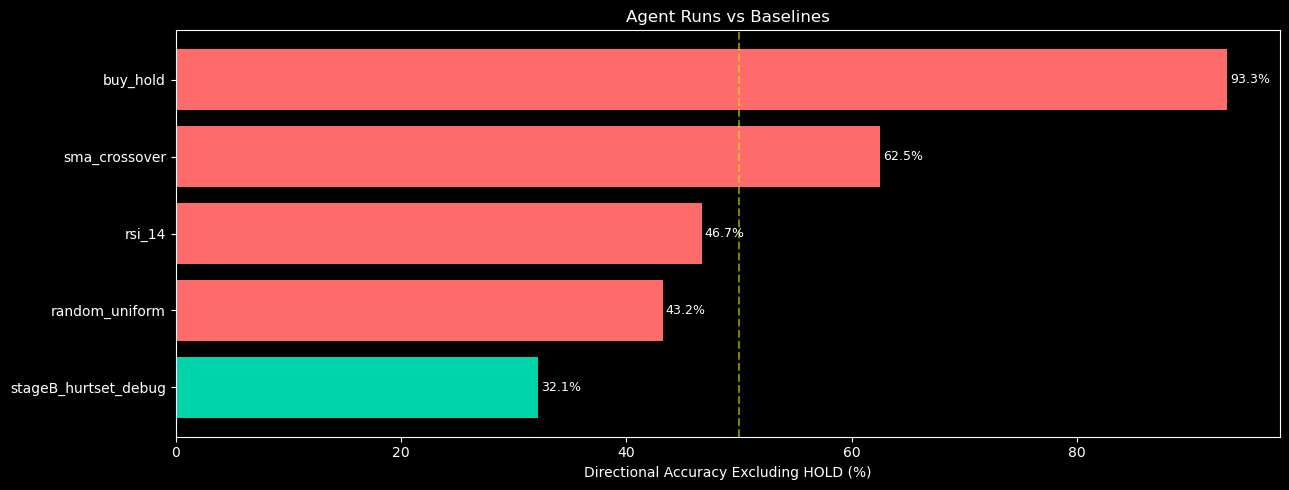

Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\stageB_hurtset_debug\chart_dir_acc_ex_hold.png


In [269]:
plot_df = pd.DataFrame()
if not agent_summary.empty:
    plot_df = pd.concat([plot_df, agent_summary.assign(group="agent")[["name", "dir_acc_ex_hold_%", "group"]]], ignore_index=True)
if not baseline_summary.empty:
    plot_df = pd.concat([plot_df, baseline_summary.assign(group="baseline")[["name", "dir_acc_ex_hold_%", "group"]]], ignore_index=True)

plot_df = plot_df.dropna(subset=["dir_acc_ex_hold_%"]).sort_values("dir_acc_ex_hold_%", ascending=True).reset_index(drop=True)

if not plot_df.empty:
    
    fig, ax = plt.subplots(figsize=(13, max(5, 0.55 * len(plot_df))))
    colors = ["#00d4aa" if g == "agent" else "#ff6b6b" for g in plot_df["group"]]
    ax.barh(plot_df["name"], plot_df["dir_acc_ex_hold_%"], color=colors)
    ax.axvline(50, color="yellow", linestyle="--", alpha=0.5)
    ax.set_xlabel("Directional Accuracy Excluding HOLD (%)")
    ax.set_title("Agent Runs vs Baselines")
    for y, v in enumerate(plot_df["dir_acc_ex_hold_%"]):
        ax.text(v + 0.25, y, f"{v:.1f}%", va="center", fontsize=9)
    plt.tight_layout()
    chart_path = bundle_dir / "chart_dir_acc_ex_hold.png"
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", chart_path)
else:
    print("No rows to plot.")

## 9) Paired Run Comparison (Same Ticker/Date/Horizon)

In [211]:
# Pick tags for paired comparison
curr_tag = agent_summary.iloc[0]["name"] if not agent_summary.empty else None
prev_tag = "batch_eval50_stageA_v8_lean_20260305_150806"

registry_df = pd.read_csv(AGENT_REGISTRY_PATH) if AGENT_REGISTRY_PATH.exists() else analysis_agent_df.copy()

if curr_tag is None:
    print("No current run available.")
elif prev_tag is None:
    print("Set prev_tag to enable paired comparison.")
else:
    curr = registry_df[registry_df["run_tag"].eq(curr_tag)].copy()
    prev = registry_df[registry_df["run_tag"].eq(prev_tag)].copy()
    keys = ["ticker", "simulated_date", "horizon"]

    keep_cols = keys + ["action", "k_return", "correct"]
    c = curr[keep_cols].rename(columns={"action": "action_curr", "k_return": "k_return_curr", "correct": "correct_curr"})
    p = prev[keep_cols].rename(columns={"action": "action_prev", "k_return": "k_return_prev", "correct": "correct_prev"})

    paired = c.merge(p, on=keys, how="inner")
    print(f"curr={curr_tag} rows={len(c)} | prev={prev_tag} rows={len(p)} | overlap={len(paired)}")

    if not paired.empty:
        paired["k_return"] = paired["k_return_curr"].fillna(paired["k_return_prev"])

        def strat_ret(action, kret):
            if pd.isna(kret):
                return np.nan
            if action == "BUY":
                return kret
            if action == "SELL":
                return -kret
            return 0.0

        paired["ret_curr"] = [strat_ret(a, r) for a, r in zip(paired["action_curr"], paired["k_return"])]
        paired["ret_prev"] = [strat_ret(a, r) for a, r in zip(paired["action_prev"], paired["k_return"])]
        paired["excess_curr"] = paired["ret_curr"] - paired["k_return"]
        paired["excess_prev"] = paired["ret_prev"] - paired["k_return"]

        curr_dir = paired[paired["action_curr"].isin(["BUY", "SELL"])]["correct_curr"].mean() * 100
        prev_dir = paired[paired["action_prev"].isin(["BUY", "SELL"])]["correct_prev"].mean() * 100

        cmp = pd.DataFrame([
            ["overall_acc_%", paired["correct_curr"].mean() * 100, paired["correct_prev"].mean() * 100],
            ["dir_acc_ex_hold_%", curr_dir, prev_dir],
            ["hold_rate_%", paired["action_curr"].eq("HOLD").mean() * 100, paired["action_prev"].eq("HOLD").mean() * 100],
            ["mean_strategy_return_%", paired["ret_curr"].mean() * 100, paired["ret_prev"].mean() * 100],
            ["mean_excess_vs_bh_%", paired["excess_curr"].mean() * 100, paired["excess_prev"].mean() * 100],
        ], columns=["metric", curr_tag, prev_tag])
        cmp["delta"] = cmp[curr_tag] - cmp[prev_tag]
        cmp = cmp.round(3)
        display(cmp)

        paired_out = bundle_dir / f"paired_{curr_tag}_vs_{prev_tag}.csv"
        cmp_out = bundle_dir / f"paired_summary_{curr_tag}_vs_{prev_tag}.csv"
        paired.to_csv(paired_out, index=False)
        cmp.to_csv(cmp_out, index=False)
        print("Saved:", paired_out.name)
        print("Saved:", cmp_out.name)

curr=eval125_stageB_v4.5_lean rows=125 | prev=batch_eval50_stageA_v8_lean_20260305_150806 rows=0 | overlap=0


## 9B) Stage A vs Stage B — Date-Matched Comparison (Fair Ablation)

Stage B ran on `dates_eval50.txt` (10 dates × 5 tickers = 50 rows).
Stage A ran on `dates_expanded.txt` (77 dates × 5 tickers = 385 rows).

**To compare fairly:** extract Stage A rows for the exact same 10 dates from the 385-row registry, then compare side-by-side on identical ticker/date pairs.

The delta on matched rows is the only valid A→B signal. Any other comparison measures distribution shift, not architecture.

In [270]:
# ── Stage A vs Stage B — explicit date-matched fair ablation ───────────────────
"""
Build the fair A/B comparison set from an explicit date list.
This avoids accidental distribution mismatch when one file covers more dates than the other.
"""

STAGE_A_FILE = "batch_eval50_stageA_v10_full385_lean_20260305_153846.jsonl"
STAGE_B_FILE = "batch_stageB_hurtset_debug_20260309_223348.jsonl"
DATES_FILE = ROOT / "inputs" / "dates_expanded.txt"

def load_date_list(path: Path) -> list[str]:
    dates = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            d = line.strip()
            if d:
                dates.append(d)
    return dates

EVAL_DATES = load_date_list(DATES_FILE)
print(f"Loaded {len(EVAL_DATES)} target dates from {DATES_FILE.name}")

def load_run_filtered(filename: str, label: str, allowed_dates: set[str] | None = None) -> pd.DataFrame:
    rows = []
    p = RAW_DIR / filename
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if "error" in obj:
                continue

            ticker = obj.get("ticker")
            sim_date = obj.get("simulated_date")
            if allowed_dates is not None and sim_date not in allowed_dates:
                continue

            horizon = obj.get("horizon", "short")
            k = HORIZON_MAP.get(horizon, 10)
            action = extract_agent_action(obj)
            ret = k_return(ticker, sim_date, k)
            ts = ((obj.get("result") or {}).get("trading_strategy") or {})

            rows.append({
                "ticker": ticker,
                "simulated_date": sim_date,
                f"action_{label}": action,
                f"conf_{label}": float(ts.get("confidence_score") or 0),
                "k_return": ret,
                f"correct_{label}": directional_correct(action, ret),
            })
    return pd.DataFrame(rows)

allowed_dates = set(EVAL_DATES)
a_dates = load_run_filtered(STAGE_A_FILE, "A", allowed_dates=allowed_dates)
b_dates = load_run_filtered(STAGE_B_FILE, "B", allowed_dates=allowed_dates)

ab = a_dates.merge(
    b_dates.drop(columns="k_return"),
    on=["ticker", "simulated_date"],
    how="inner"
).sort_values(["simulated_date", "ticker"]).reset_index(drop=True)

print(f"Stage A filtered rows: {len(a_dates)}")
print(f"Stage B filtered rows: {len(b_dates)}")
print(f"Matched A/B rows:      {len(ab)}")
print(f"Matched dates:         {ab['simulated_date'].nunique() if not ab.empty else 0}")
print(f"Matched tickers:       {ab['ticker'].nunique() if not ab.empty else 0}")

missing_a = sorted(set(EVAL_DATES) - set(a_dates["simulated_date"].dropna().unique()))
missing_b = sorted(set(EVAL_DATES) - set(b_dates["simulated_date"].dropna().unique()))
if missing_a:
    print("Missing in Stage A:", missing_a)
if missing_b:
    print("Missing in Stage B:", missing_b)

def metrics(df, suffix):
    act = df[f"action_{suffix}"]
    cor = df[f"correct_{suffix}"]
    dir_rows = act.isin(["BUY", "SELL"])
    return {
        "stage": f"Stage {suffix}",
        "n": len(df),
        "overall_acc_%": round(cor.mean() * 100, 2),
        "dir_acc_ex_hold_%": round(cor[dir_rows].mean() * 100, 2) if dir_rows.any() else float("nan"),
        "dir_n": int(dir_rows.sum()),
        "buy_acc_%": round(cor[act == "BUY"].mean() * 100, 2) if (act == "BUY").any() else float("nan"),
        "sell_acc_%": round(cor[act == "SELL"].mean() * 100, 2) if (act == "SELL").any() else float("nan"),
        "buy_n": int((act == "BUY").sum()),
        "sell_n": int((act == "SELL").sum()),
        "hold_n": int((act == "HOLD").sum()),
        "hold_rate_%": round((act == "HOLD").mean() * 100, 2),
    }

summary = pd.DataFrame([metrics(ab, "A"), metrics(ab, "B")])
if not summary.empty:
    summary["delta_vs_A"] = summary["dir_acc_ex_hold_%"] - summary.loc[summary.stage == "Stage A", "dir_acc_ex_hold_%"].values[0]
print("\n=== Head-to-head on explicit date-matched rows ===")
display(summary.set_index("stage"))

for suffix in ["A", "B"]:
    dir_rows = ab[ab[f"action_{suffix}"].isin(["BUY", "SELL"])] .copy()
    mean, lo, hi = bootstrap_ci_mean(dir_rows[f"correct_{suffix}"].values * 100)
    print(f"Stage {suffix} dir_acc: {mean:.1f}%  95% CI [{lo:.1f}%, {hi:.1f}%]  n={len(dir_rows)}")

ab["flipped"] = ab["action_A"] != ab["action_B"]
ab["true_label"] = ab["k_return"].apply(true_direction_label)
flips = ab[ab["flipped"]].copy()

print(f"\nDecision flips: {len(flips)} / {len(ab)}")
if not flips.empty:
    flips["flip_correct"] = flips["correct_B"]
    flips["flip_helped"] = (flips["correct_A"] == 0) & (flips["correct_B"] == 1)
    flips["flip_hurt"] = (flips["correct_A"] == 1) & (flips["correct_B"] == 0)

    display_cols = [
        "ticker", "simulated_date", "action_A", "action_B",
        "true_label", "k_return", "correct_A", "correct_B",
        "flip_helped", "flip_hurt"
    ]

    flips = flips[display_cols].sort_values("k_return", key=abs, ascending=False).reset_index(drop=True)
    hurt_set = flips[flips["flip_hurt"]].copy().reset_index(drop=True)
    helped_set = flips[flips["flip_helped"]].copy().reset_index(drop=True)

    print(f"  Flips that HELPED (A wrong → B right): {len(helped_set)}")
    print(f"  Flips that HURT  (A right → B wrong):  {len(hurt_set)}")
    print(f"  Neutral flips (both same outcome):      {len(flips) - len(helped_set) - len(hurt_set)}")

    with pd.option_context(
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None,
        "display.max_colwidth", None
    ):
        display(flips)

    if "bundle_dir" in globals() and bundle_dir.exists():
        matched_path = bundle_dir / "stageA_stageB_date_matched_rows.csv"
        flips_path = bundle_dir / "stageA_stageB_flips_all.csv"
        hurt_path = bundle_dir / "stageA_right_stageB_wrong.csv"
        helped_path = bundle_dir / "stageA_wrong_stageB_right.csv"

        ab.to_csv(matched_path, index=False)
        flips.to_csv(flips_path, index=False)
        hurt_set.to_csv(hurt_path, index=False)
        helped_set.to_csv(helped_path, index=False)

        print("Saved:", matched_path)
        print("Saved:", flips_path)
        print("Saved:", hurt_path)
        print("Saved:", helped_path)

agree = ab[~ab["flipped"]]
print(f"\nAgreement rate: {len(agree)}/{len(ab)} ({len(agree)/len(ab)*100:.0f}%)")
print(f"  Accuracy on agreed rows:   A={agree['correct_A'].mean()*100:.1f}%  B={agree['correct_B'].mean()*100:.1f}%")
if not flips.empty:
    print(f"  Accuracy on flipped rows:  A={flips['correct_A'].mean()*100:.1f}%  B={flips['correct_B'].mean()*100:.1f}%")

Loaded 77 target dates from dates_expanded.txt


$AAPL: possibly delisted; no price data found  (1d 2025-04-28 -> 2025-06-07)


Stage A filtered rows: 385
Stage B filtered rows: 60
Matched A/B rows:      60
Matched dates:         40
Matched tickers:       5
Missing in Stage B: ['2021-09-13', '2021-10-04', '2021-10-25', '2021-12-06', '2022-02-07', '2022-03-21', '2022-04-11', '2022-05-02', '2022-06-13', '2022-07-04', '2022-08-15', '2022-09-05', '2022-11-07', '2023-02-20', '2023-04-03', '2023-06-05', '2023-08-07', '2023-08-28', '2023-09-18', '2023-10-09', '2023-11-20', '2024-01-01', '2024-02-12', '2024-03-25', '2024-05-06', '2024-05-27', '2024-07-29', '2024-08-19', '2024-10-21', '2024-12-02', '2024-12-23', '2025-02-24', '2025-03-17', '2025-05-19', '2025-09-01', '2025-11-24', '2026-01-05']

=== Head-to-head on explicit date-matched rows ===


,n,overall_acc_%,dir_acc_ex_hold_%,dir_n,buy_acc_%,sell_acc_%,buy_n,sell_n,hold_n,hold_rate_%,delta_vs_A
stage,,,,,,,,,,,
Stage A,60,100.00,100.00,58,100.00,100.00,55,3,2,3.33,0.00
Stage B,60,21.67,32.14,28,85.71,14.29,7,21,32,53.33,-67.86


Stage A dir_acc: 100.0%  95% CI [100.0%, 100.0%]  n=58
Stage B dir_acc: 32.1%  95% CI [14.3%, 50.0%]  n=28

Decision flips: 51 / 60
  Flips that HELPED (A wrong → B right): 0
  Flips that HURT  (A right → B wrong):  47
  Neutral flips (both same outcome):      4


,ticker,simulated_date,action_A,action_B,true_label,k_return,correct_A,correct_B,flip_helped,flip_hurt
0,NVDA,2025-02-03,BUY,SELL,BUY,0.194925,1.0,0,False,True
1,XOM,2022-09-26,BUY,HOLD,BUY,0.176947,1.0,0,False,True
2,XOM,2026-01-26,BUY,HOLD,BUY,0.121403,1.0,0,False,True
3,NVDA,2022-05-23,BUY,SELL,BUY,0.120014,1.0,0,False,True
4,NVDA,2022-11-28,BUY,HOLD,BUY,0.108200,1.0,0,False,True
5,AAPL,2021-11-15,BUY,HOLD,BUY,0.102000,1.0,0,False,True
6,JPM,2025-04-07,BUY,SELL,BUY,0.098629,1.0,0,False,True
7,NVDA,2024-09-09,BUY,HOLD,BUY,0.092044,1.0,0,False,True
8,AAPL,2023-10-30,BUY,SELL,BUY,0.086638,1.0,0,False,True
9,JNJ,2025-09-22,BUY,SELL,BUY,0.080076,1.0,0,False,True


Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\stageB_hurtset_debug\stageA_stageB_date_matched_rows.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\stageB_hurtset_debug\stageA_stageB_flips_all.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\stageB_hurtset_debug\stageA_right_stageB_wrong.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\stageB_hurtset_debug\stageA_wrong_stageB_right.csv

Agreement rate: 9/60 (15%)
  Accuracy on agreed rows:   A=100.0%  B=100.0%
  Accuracy on flipped rows:  A=100.0%  B=7.8%


In [256]:
# ── Date coverage audit + full hurt/helped extraction ─────────────────────────
"""
Supplementary audit for the explicit A/B date set.
Shows where dates came from, which dates exist in each raw JSONL, and extracts the exact hurt/helped sets.
"""

print("DATES_FILE:", DATES_FILE)
date_input_df = pd.DataFrame({
    "input_date": EVAL_DATES,
    "input_order": range(1, len(EVAL_DATES) + 1),
})
display(date_input_df)

def extract_present_dates(filename: str) -> pd.DataFrame:
    rows = []
    p = RAW_DIR / filename
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if "error" in obj:
                continue
            rows.append({
                "ticker": obj.get("ticker"),
                "simulated_date": obj.get("simulated_date"),
            })
    return pd.DataFrame(rows)

a_present = extract_present_dates(STAGE_A_FILE)
b_present = extract_present_dates(STAGE_B_FILE)

a_counts = (
    a_present.groupby("simulated_date")
    .agg(stageA_rows=("ticker", "size"), stageA_tickers=("ticker", "nunique"))
    .reset_index()
    if not a_present.empty else pd.DataFrame(columns=["simulated_date", "stageA_rows", "stageA_tickers"])
 )

b_counts = (
    b_present.groupby("simulated_date")
    .agg(stageB_rows=("ticker", "size"), stageB_tickers=("ticker", "nunique"))
    .reset_index()
    if not b_present.empty else pd.DataFrame(columns=["simulated_date", "stageB_rows", "stageB_tickers"])
 )

date_audit = (
    date_input_df.rename(columns={"input_date": "simulated_date"})
    .merge(a_counts, on="simulated_date", how="left")
    .merge(b_counts, on="simulated_date", how="left")
    .fillna({
        "stageA_rows": 0,
        "stageA_tickers": 0,
        "stageB_rows": 0,
        "stageB_tickers": 0,
    })
 )

for col in ["stageA_rows", "stageA_tickers", "stageB_rows", "stageB_tickers"]:
    date_audit[col] = date_audit[col].astype(int)

date_audit["in_stage_A"] = date_audit["stageA_rows"] > 0
date_audit["in_stage_B"] = date_audit["stageB_rows"] > 0
date_audit["matched_in_both"] = date_audit["in_stage_A"] & date_audit["in_stage_B"]
date_audit["full_5ticker_overlap"] = (date_audit["stageA_tickers"] == 5) & (date_audit["stageB_tickers"] == 5)

print("\n=== Date coverage audit ===")
display(date_audit)

if not ab.empty:
    per_date_match = (
        ab.groupby("simulated_date")
        .agg(
            matched_rows=("ticker", "size"),
            matched_tickers=("ticker", "nunique"),
            A_buy=("action_A", lambda s: int((s == "BUY").sum())),
            A_sell=("action_A", lambda s: int((s == "SELL").sum())),
            A_hold=("action_A", lambda s: int((s == "HOLD").sum())),
            B_buy=("action_B", lambda s: int((s == "BUY").sum())),
            B_sell=("action_B", lambda s: int((s == "SELL").sum())),
            B_hold=("action_B", lambda s: int((s == "HOLD").sum())),
        )
        .reset_index()
        .sort_values("simulated_date")
    )
    print("\n=== Matched A/B rows by date ===")
    display(per_date_match)

if not flips.empty:
    print("\n=== Stage A right / Stage B wrong ===")
    display(hurt_set)

    print("\n=== Stage A wrong / Stage B right ===")
    display(helped_set)

    if "bundle_dir" in globals() and bundle_dir.exists():
        date_audit_path = bundle_dir / "stageA_stageB_date_audit.csv"
        date_audit.to_csv(date_audit_path, index=False)
        print("Saved:", date_audit_path)

DATES_FILE: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\inputs\dates.txt


,input_date,input_order
0,2025-03-03,1
1,2025-03-17,2
2,2025-03-31,3
3,2025-04-14,4
4,2025-04-28,5
5,2025-05-12,6
6,2025-05-26,7
7,2025-06-09,8
8,2025-06-23,9
9,2025-07-07,10



=== Date coverage audit ===


,simulated_date,input_order,stageA_rows,stageA_tickers,stageB_rows,stageB_tickers,in_stage_A,in_stage_B,matched_in_both,full_5ticker_overlap
0,2025-03-03,1,0,0,0,0,False,False,False,False
1,2025-03-17,2,5,5,5,5,True,True,True,True
2,2025-03-31,3,0,0,0,0,False,False,False,False
3,2025-04-14,4,0,0,0,0,False,False,False,False
4,2025-04-28,5,5,5,5,5,True,True,True,True
5,2025-05-12,6,0,0,0,0,False,False,False,False
6,2025-05-26,7,0,0,0,0,False,False,False,False
7,2025-06-09,8,5,5,5,5,True,True,True,True
8,2025-06-23,9,0,0,0,0,False,False,False,False
9,2025-07-07,10,0,0,0,0,False,False,False,False



=== Matched A/B rows by date ===


...


=== Stage A right / Stage B wrong ===


,ticker,simulated_date,action_A,action_B,true_label,k_return,correct_A,correct_B,flip_helped,flip_hurt
0,NVDA,2025-07-21,BUY,HOLD,BUY,0.050297,1,0,False,True
1,NVDA,2025-06-09,BUY,HOLD,BUY,0.037021,1,0,False,True
2,XOM,2025-10-13,BUY,HOLD,BUY,0.032965,1,0,False,True
3,JNJ,2025-04-28,HOLD,BUY,HOLD,-0.007789,1,0,False,True



=== Stage A wrong / Stage B right ===


,ticker,simulated_date,action_A,action_B,true_label,k_return,correct_A,correct_B,flip_helped,flip_hurt
0,JNJ,2025-11-24,BUY,HOLD,HOLD,-0.023394,0,1,True,False
1,JNJ,2025-03-17,SELL,HOLD,HOLD,0.018423,0,1,True,False
2,JNJ,2025-09-01,BUY,HOLD,HOLD,-0.008986,0,1,True,False
3,AAPL,2025-06-09,BUY,SELL,HOLD,-0.005709,0,1,True,False
4,XOM,2025-09-01,BUY,HOLD,HOLD,-0.000087,0,1,True,False


Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\eval385_stageB_v5_lean\stageA_stageB_date_audit.csv


## 9C) Stage B Flip Pattern Audit — Root Cause and Architectural Fix

### Stage B v2 (373 rows) — Tournament model diagnosis

| Metric | Stage A | Stage B v2 | Delta |
|---|---|---|---|
| dir_acc_ex_hold | 61.0% | 56.1% | −4.9pp |
| hold_rate | ~35% | ~37% | +2pp |
| BUY→SELL flips | — | 36 (24 on UP days) | Bear forcing wrong SELLs |

**Root cause (v2):** The Bear prompt mandated "make the strongest SELL case" — a mandatory SELL directive. Even when all analyst signals were BULLISH, Bear constructed the best available SELL argument because the task demanded it. The Manager heard one BUY argument and one SELL argument of roughly equal weight, and occasionally chose SELL — flipping correct BUYs to wrong SELLs on UP dates.

### Stage B v3 (50 rows) — fix_bear attempt

Bear was reframed from "mandatory SELL prosecutor" to "stress-tester with free STANCE" (`batch_eval50_stageB_fix_bear_lean_20260306_131027.jsonl`). Still net-negative: 5 HURT vs 2 HELPED (−5.2pp vs Stage A 61.2%).

**Deepened diagnosis:** The root problem is not the Bear prompt wording — it's the tournament architecture itself. Both advocates receive **identical inputs** (the same signal summary). Giving them opposite mandates manufactures conflict from the same evidence. The Manager then resolves a manufactured dispute rather than reading the evidence directly — which is exactly what Stage A already does, better. Fixing the mandate wording fiddled with tournament rules without eliminating the tournament.

### Stage B v4 — Architectural fix: evidence extraction not tournament

The debate mechanism is replaced with structured evidence extraction:

| Slot | v1–v3 | v4 |
|---|---|---|
| Bull slot | THESIS + BUY_EVIDENCE + STANCE (BUY mandate) | TOP_UPSIDE_CATALYSTS + UPSIDE_FAILURE (no STANCE) |
| Bear slot | THESIS + SELL_EVIDENCE + STANCE (SELL/stress mandate) | TOP_DOWNSIDE_RISKS + RISK_IRRELEVANCE (no STANCE) |
| Manager | Tournament judge — picks winner | Independent synthesiser — reads full reports; highlights are attention directors |

**Run pending:** `eval50_stageB_v4_extraction` batch not yet executed. Expected: HELPED > HURT with conservative flip profile (fewer flips overall, higher quality).

In [104]:
def flip_type(row):
    a, b = row["action_A"], row["action_B"]
    if a == b:
        return "same"
    if a == "BUY" and b == "SELL":
        return "BUY→SELL"
    if a == "SELL" and b == "BUY":
        return "SELL→BUY"
    if a == "BUY" and b == "HOLD":
        return "BUY→HOLD"
    if a == "SELL" and b == "HOLD":
        return "SELL→HOLD"
    if a == "HOLD" and b == "BUY":
        return "HOLD→BUY"
    if a == "HOLD" and b == "SELL":
        return "HOLD→SELL"
    return "other"

flips = flips.copy()
flips["flip_type"] = flips.apply(flip_type, axis=1)

# ── 2. Per flip-type: helped, hurt, net ───────────────────────────────────
flip_stats = (
    flips.groupby("flip_type")
    .agg(
        count=("flip_helped", "size"),
        helped=("flip_helped", "sum"),
        hurt=("flip_hurt", "sum"),
    )
    .assign(net=lambda d: d["helped"] - d["hurt"])
    .sort_values("count", ascending=False)
    .reset_index()
)
print("=== Flip breakdown by direction-change type ===")
display(flip_stats)

# ── 3. BUY→SELL flips: market direction at time of flip ───────────────────
buy_to_sell = flips[flips["flip_type"] == "BUY→SELL"].copy()
mkt_up   = (buy_to_sell["k_return"] > 0).sum()
mkt_down = (buy_to_sell["k_return"] < 0).sum()
mkt_hold = (buy_to_sell["k_return"].abs() < HOLD_EPSILON).sum()

print(f"\nBUY→SELL flips: total={len(buy_to_sell)}")
print(f"  market went UP  (B wrong): {mkt_up}  ({100*mkt_up/max(len(buy_to_sell),1):.0f}%)")
print(f"  market went DN  (B right): {mkt_down}  ({100*mkt_down/max(len(buy_to_sell),1):.0f}%)")
print(f"  market HOLD zone:          {mkt_hold}")

# ── 4. SELL volume and accuracy shift ────────────────────────────────────
total = len(ab)
a_sell_n = (ab["action_A"] == "SELL").sum()
b_sell_n = (ab["action_B"] == "SELL").sum()
a_sell_acc = ab.loc[ab["action_A"] == "SELL", "correct_A"].mean() * 100
b_sell_acc = ab.loc[ab["action_B"] == "SELL", "correct_B"].mean() * 100
a_buy_n    = (ab["action_A"] == "BUY").sum()
b_buy_n    = (ab["action_B"] == "BUY").sum()

print(f"\n=== Advocate impact on call distribution ===")
print(f"  SELL calls:  A={a_sell_n}  B={b_sell_n}  Δ={b_sell_n - a_sell_n:+d}")
print(f"  BUY calls:   A={a_buy_n}  B={b_buy_n}  Δ={b_buy_n - a_buy_n:+d}")
print(f"  SELL acc:    A={a_sell_acc:.1f}%  B={b_sell_acc:.1f}%  Δ={b_sell_acc - a_sell_acc:+.1f}pp")

# ── 5. True label distribution on evaluation set ─────────────────────────
tl = ab["true_label"].value_counts()
total_nna = ab["true_label"].dropna().__len__()
print(f"\n=== True label distribution (evaluation set composition) ===")
for label, ct in tl.items():
    print(f"  {label}: {ct} / {total_nna}  ({100*ct/total_nna:.0f}%)")

buy_heavy = tl.get("BUY", 0) > tl.get("SELL", 0)
if buy_heavy:
    print(f"\n⚠ Evaluation set is BUY-heavy:")
    print(f"  → Tournament Bear forcing extra SELLs on BUY dates = dominant failure mode.")

# ── 6. Architecture note ─────────────────────────────────────────────────
print(f"\n=== Stage B v4 — Architectural fix (evidence extraction) ===")
print(f"  v2/v3 problem: both advocates had identical inputs (signal summary) + opposite mandates.")
print(f"  Manufactured conflict → Manager resolves a dispute it'd solve better reading reports directly.")
print(f"  v4 fix: Bull slot → Upside Catalyst Analyst (TOP_UPSIDE_CATALYSTS, no STANCE)")
print(f"          Bear slot → Downside Risk Analyst (TOP_DOWNSIDE_RISKS, no STANCE)")
print(f"          Manager  → Independent Synthesiser (reads full reports; highlights = attention directors)")
print(f"  Expected: conservative flip profile (fewer total flips), HELPED > HURT.")
print(f"  v4 batch (eval50_stageB_v4_extraction): PENDING — run to validate.")


=== Flip breakdown by direction-change type ===


,flip_type,count,helped,hurt,net
0,BUY→SELL,36,12,24,-12
1,SELL→BUY,10,7,3,4
2,HOLD→BUY,8,4,2,2
3,HOLD→SELL,3,2,0,2
4,BUY→HOLD,1,0,0,0
5,SELL→HOLD,1,0,0,0



BUY→SELL flips: total=36
  market went UP  (B wrong): 24  (67%)
  market went DN  (B right): 12  (33%)
  market HOLD zone:          9

=== Bear advocate impact on call distribution ===
  SELL calls:  A=106  B=134  Δ=+28  (Bear pushed 28 extra SELLs)
  BUY calls:   A=254  B=235  Δ=-19
  SELL acc:    A=48.1%  B=46.3%  Δ=-1.8pp

  The 28 extra Stage B SELLs come predominantly from converted BUYs.
  Of BUY→SELL flips where market went UP: 24 / 36 were Bear forcing wrong SELL.

=== True label distribution (evaluation set composition) ===
  BUY: 159 / 373  (43%)
  HOLD: 116 / 373  (31%)
  SELL: 98 / 373  (26%)

  Key: if evaluation set is BUY-heavy, an overclaiming Bear always hurts more than it helps.

⚠ Evaluation set is BUY-heavy:
  → Bear forcing extra SELLs on BUY dates = the dominant failure mode.
  → Fix: add falsifiability gate to Stage B Bear prompt
         (same rule as C/D: if 2/3 signals BULLISH ≥0.65, Bear cannot output SELL)
  → This is a prompt constraint, not a post-LLM ove

In [272]:
# ── Hurt-set rationale audit: BUY->HOLD vs BUY->SELL ─────────────────────────
"""
Diagnose the exact language patterns behind Stage B harm cases on the hurt-set rerun.
Focus: separate suppressed BUYs (BUY->HOLD) from inverted BUYs (BUY->SELL).
"""

def load_stage_decision_text(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if "error" in obj:
                continue
            ts = ((obj.get("result") or {}).get("trading_strategy") or {})
            rows.append({
                "ticker": obj.get("ticker"),
                "simulated_date": obj.get("simulated_date"),
                "action_B": (ts.get("action") or "HOLD").upper(),
                "confidence_B": float(ts.get("confidence_score")) if ts.get("confidence_score") is not None else np.nan,
                "rationale_B": ts.get("rationale") or "",
            })
    return pd.DataFrame(rows)

if 'hurt_set' not in globals() or hurt_set.empty:
    print("No hurt_set available. Run the Stage A vs Stage B comparison cell first.")
else:
    b_diag = load_stage_decision_text(RAW_DIR / STAGE_B_FILE)
    
    hurt_diag = hurt_set.merge(
        b_diag,
        on=['ticker', 'simulated_date', 'action_B'],
        how='left'
    ).copy()
    
    if 'flip_type' not in hurt_diag.columns:
        hurt_diag['flip_type'] = hurt_diag['action_A'] + '→' + hurt_diag['action_B']
    
    marker_patterns = {
        'seller_control': r'\b(seller control|active seller control|bearish short-term trend|broken short-term trend|trading significantly below|trading below|below the sma|below sma|sellers maintain control)\b',
        'low_conviction': r'\b(lacks conviction|low volume|susceptible to exhaustion|highly susceptible to exhaustion|fragile|uncertain|uncertainty|cautious|wait)\b',
        'breakdown_risk': r'\b(breakdown|downside momentum|decisive breach|no-floor|overrides? .* signals|accelerate downside|sell-off|seller control)\b',
        'mean_reversion': r'\b(mean-reversion|oversold|overbought|bollinger|rsi|macd)\b',
        'event_risk': r'\b(earnings report|guidance|launch|news|article|analyst|target upgrade|upgrade|downgrade|supply chain)\b',
        'fundamental_caution': r'\b(revenue|margin|gross margin|growth rate|fundamental concerns|cost of revenue|liquidity)\b',
    }
    
    for name, pat in marker_patterns.items():
        hurt_diag[name] = hurt_diag['rationale_B'].fillna('').str.contains(pat, case=False, regex=True)
    
    print('=== Hurt cases by flip type ===')
    flip_breakdown = (
        hurt_diag.groupby('flip_type')
        .agg(
            n=('ticker', 'size'),
            mean_k_return=('k_return', 'mean'),
            median_k_return=('k_return', 'median'),
            mean_conf_B=('confidence_B', 'mean'),
        )
        .sort_values('n', ascending=False)
        .round(4)
        .reset_index()
    )
    display(flip_breakdown)
    
    print('\n=== Marker frequency within hurt cases (%) ===')
    marker_rate = (
        hurt_diag.groupby('flip_type')[list(marker_patterns.keys())]
        .mean()
        .mul(100)
        .round(1)
        .reset_index()
    )
    display(marker_rate)
    
    print('\n=== BUY->HOLD vs BUY->SELL summary ===')
    compact = hurt_diag[hurt_diag['flip_type'].isin(['BUY→HOLD', 'BUY→SELL'])].copy()
    if compact.empty:
        print('No BUY→HOLD / BUY→SELL hurt rows found.')
    else:
        summary_rows = []
        for ft, g in compact.groupby('flip_type'):
            row = {
                'flip_type': ft,
                'n': len(g),
                'mean_return_%': round(g['k_return'].mean() * 100, 2),
                'median_return_%': round(g['k_return'].median() * 100, 2),
                'mean_conf_B': round(g['confidence_B'].mean(), 3),
            }
            for name in marker_patterns:
                row[name + '_%'] = round(g[name].mean() * 100, 1)
            summary_rows.append(row)
        display(pd.DataFrame(summary_rows).sort_values('n', ascending=False))
    
    print('\n=== Representative BUY->SELL harm cases ===')
    b2s_cols = ['ticker', 'simulated_date', 'k_return', 'confidence_B', 'rationale_B']
    display(
        hurt_diag[hurt_diag['flip_type'].eq('BUY→SELL')][b2s_cols]
        .sort_values('k_return', ascending=False)
        .head(10)
    )
    
    print('\n=== Representative BUY->HOLD harm cases ===')
    b2h_cols = ['ticker', 'simulated_date', 'k_return', 'confidence_B', 'rationale_B']
    display(
        hurt_diag[hurt_diag['flip_type'].eq('BUY→HOLD')][b2h_cols]
        .sort_values('k_return', ascending=False)
        .head(10)
    )
    
    if 'bundle_dir' in globals() and bundle_dir.exists():
        hurt_diag_path = bundle_dir / 'stageB_hurt_rationale_audit.csv'
        marker_rate_path = bundle_dir / 'stageB_hurt_marker_rates.csv'
        hurt_diag.to_csv(hurt_diag_path, index=False)
        marker_rate.to_csv(marker_rate_path, index=False)
        print('\nSaved:', hurt_diag_path)
        print('Saved:', marker_rate_path)

=== Hurt cases by flip type ===


,flip_type,n,mean_k_return,median_k_return,mean_conf_B
0,BUY→HOLD,28,0.0597,0.0489,0.7464
1,BUY→SELL,18,0.0685,0.0633,0.7028
2,SELL→BUY,1,-0.0084,-0.0084,0.6500



=== Marker frequency within hurt cases (%) ===


,flip_type,seller_control,low_conviction,breakdown_risk,mean_reversion,event_risk,fundamental_caution
0,BUY→HOLD,3.6,7.1,42.9,53.6,17.9,39.3
1,BUY→SELL,77.8,0.0,50.0,44.4,0.0,33.3
2,SELL→BUY,0.0,100.0,0.0,0.0,0.0,0.0



=== BUY->HOLD vs BUY->SELL summary ===


...


=== Representative BUY->SELL harm cases ===


,ticker,simulated_date,k_return,confidence_B,rationale_B
0,NVDA,2025-02-03,0.194925,0.70,FOR: Price vs. SMA: Price (116.63) is trading ...
3,NVDA,2022-05-23,0.120014,0.75,FOR: Price vs SMA_20: Current price (16.87) is...
6,JPM,2025-04-07,0.098629,0.75,FOR: Price (211.43) is trading significantly b...
8,AAPL,2023-10-30,0.086638,0.65,FOR: SMA_20 -> 172.88 -> Price (168.32) is sus...
9,JNJ,2025-09-22,0.080076,0.65,FOR: Price (172.2) has broken below the 20-day...
11,AAPL,2022-10-17,0.076750,0.70,FOR: Price vs SMA: 139.93 remains below the SM...
12,AAPL,2025-02-03,0.073369,0.65,FOR: Price vs. SMAs: Price (226.77) is trading...
13,JPM,2024-06-17,0.071033,0.65,FOR: Price (187.88) is trading below the SMA_2...
15,XOM,2025-08-11,0.065669,0.65,FOR: **QoQ Revenue Deceleration:** Revenue fel...
17,JPM,2023-10-30,0.060836,0.75,FOR: Price vs. SMA: Current price (130.84) is ...



=== Representative BUY->HOLD harm cases ===


,ticker,simulated_date,k_return,confidence_B,rationale_B
1,XOM,2022-09-26,0.176947,0.70,FOR: Technical exhaustion indicated by RSI at ...
2,XOM,2026-01-26,0.121403,0.70,FOR: Bullish MACD momentum and price action ab...
4,NVDA,2022-11-28,0.108200,0.65,FOR: Bullish technical alignment with MACD and...
5,AAPL,2021-11-15,0.102000,0.75,FOR: Price is currently pinned to the 146.40 S...
7,NVDA,2024-09-09,0.092044,0.65,FOR: Accelerating bearish technical momentum i...
10,JNJ,2026-01-26,0.077430,0.80,FOR: Strong 2026 sales guidance and bullish MA...
14,JPM,2023-06-26,0.066401,0.75,FOR: Massive 58% revenue growth vs. severe -$1...
16,NVDA,2025-12-15,0.063815,0.75,FOR: Record 21.9% QoQ revenue growth and Nemot...
18,JNJ,2024-07-08,0.060214,0.75,FOR: Significant 44% QoQ net income growth and...
19,NVDA,2023-12-11,0.056877,0.75,FOR: Extreme fundamental momentum with 49.3% Q...



Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\stageB_hurtset_debug\stageB_hurt_rationale_audit.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\stageB_hurtset_debug\stageB_hurt_marker_rates.csv


## 10) Confidence-Band Diagnostics (Calibration View)

In [ ]:
conf_df = analysis_agent_df.copy()
conf_stats = (
    conf_df.groupby("confidence_band")
    .agg(**{
        "n": ("correct", "size"),
        "overall_acc_%": ("correct", lambda s: s.mean() * 100),
        "hold_rate_%": ("action", lambda s: (s == "HOLD").mean() * 100),
    })
    .reset_index()
    .sort_values("n", ascending=False)
)

# directional-only accuracy per confidence
rows = []
for cb, g in conf_df.groupby("confidence_band"):
    dacc, dn = directional_accuracy_ex_hold(g)
    rows.append({
        "confidence_band": cb,
        "dir_acc_ex_hold_%": dacc,
        "dir_acc_ex_hold_n": dn,
    })
dir_conf = pd.DataFrame(rows)

conf_stats = conf_stats.merge(dir_conf, on="confidence_band", how="left")
conf_stats = conf_stats.round(3)
display(conf_stats)

conf_path = bundle_dir / "confidence_diagnostics.csv"
conf_stats.to_csv(conf_path, index=False)
print("Saved:", conf_path)

if not conf_stats.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    x = conf_stats["confidence_band"].astype(str)
    y = conf_stats["dir_acc_ex_hold_%"]
    ax.bar(x, y, color="#7aa2f7")
    ax.axhline(50, color="yellow", linestyle="--", alpha=0.6)
    ax.set_ylabel("Directional Accuracy Excluding HOLD (%)")
    ax.set_title("Calibration by Confidence Band")
    plt.tight_layout()
    conf_chart = bundle_dir / "chart_confidence_calibration.png"
    plt.savefig(conf_chart, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", conf_chart)

SyntaxError: positional argument follows keyword argument (672039495.py, line 6)

## 10B) Stage-Level Diagnostics (Per-Ticker + Prompt Pattern Quality)

In [11]:
import re


def load_raw_decision_details(raw_dir: Path, pattern: str):
    rows = []
    for p in sorted(raw_dir.glob(pattern)):
        with p.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                if "error" in obj:
                    continue

                ts = ((obj.get("result") or {}).get("trading_strategy") or {})
                rationale = ts.get("rationale") or ""
                rows.append({
                    "run_file": p.name,
                    "ticker": obj.get("ticker"),
                    "simulated_date": obj.get("simulated_date"),
                    "action": (ts.get("action") or "HOLD").upper(),
                    "confidence_score": float(ts.get("confidence_score")) if ts.get("confidence_score") is not None else np.nan,
                    "rationale": rationale,
                    "has_hedge": bool(re.search(r"\b(while|despite|although|however|but)\b", rationale, re.IGNORECASE)),
                    "has_level": bool(re.search(r"\b(support|resistance|sma|bollinger|rsi|macd)\b", rationale, re.IGNORECASE)),
                    "has_fund": bool(re.search(r"\b(revenue|margin|income|cash\s*flow|guidance|growth)\b", rationale, re.IGNORECASE)),
                    "has_risk": bool(re.search(r"\b(risk|uncertain|volatility|headwind|overbought|oversold)\b", rationale, re.IGNORECASE)),
                })
    return pd.DataFrame(rows)


raw_decisions_df = load_raw_decision_details(RAW_DIR, AGENT_RUN_GLOB)

merge_keys = ["run_file", "ticker", "simulated_date", "action"]
analysis_cols = merge_keys + ["correct", "k_return", "run_tag", "horizon", "k"]

if not raw_decisions_df.empty and not analysis_agent_df.empty:
    stage_diag_df = raw_decisions_df.merge(
        analysis_agent_df[analysis_cols],
        on=merge_keys,
        how="left"
    )
else:
    stage_diag_df = pd.DataFrame()

if stage_diag_df.empty:
    print("No stage diagnostic rows available.")
else:
    per_ticker = (
        stage_diag_df.groupby("ticker")
        .agg(
            n=("correct", "size"),
            acc_pct=("correct", lambda s: s.mean() * 100),
            buy_n=("action", lambda s: (s == "BUY").sum()),
            sell_n=("action", lambda s: (s == "SELL").sum()),
            hold_n=("action", lambda s: (s == "HOLD").sum()),
            mean_confidence=("confidence_score", "mean"),
        )
        .reset_index()
        .sort_values("acc_pct", ascending=False)
        .rename(columns={"acc_pct": "acc_%"})
    )
    per_ticker = per_ticker.round({"acc_%": 2, "mean_confidence": 3})

    marker_cols = ["has_hedge", "has_level", "has_fund", "has_risk"]
    marker_rows = []
    for marker in marker_cols:
        for present in [True, False]:
            g = stage_diag_df[stage_diag_df[marker] == present]
            marker_rows.append({
                "marker": marker,
                "present": present,
                "n": int(len(g)),
                "acc_%": round(g["correct"].mean() * 100, 2) if not g.empty else np.nan,
                "mean_confidence": round(g["confidence_score"].mean(), 3) if not g.empty else np.nan,
            })
    marker_stats = pd.DataFrame(marker_rows).sort_values(["marker", "present"], ascending=[True, False])

    wrong_calls = stage_diag_df[stage_diag_df["correct"].eq(0)].copy()
    wrong_calls["abs_k_return"] = wrong_calls["k_return"].abs()
    worst_misses = wrong_calls.sort_values("abs_k_return", ascending=False).head(15)

    high_conf = stage_diag_df[stage_diag_df["confidence_score"] >= 0.75]
    print("Rows:", len(stage_diag_df))
    print("High-confidence rows (>=0.75):", len(high_conf), "| Accuracy:", round(high_conf["correct"].mean() * 100, 2) if not high_conf.empty else np.nan)

    display(per_ticker)
    display(marker_stats)
    display(worst_misses[["ticker", "simulated_date", "action", "confidence_score", "k_return", "rationale"]].head(10))

    if "bundle_dir" in globals() and bundle_dir.exists():
        per_ticker_path = bundle_dir / "stage_per_ticker_accuracy.csv"
        marker_path = bundle_dir / "stage_prompt_marker_quality.csv"
        misses_path = bundle_dir / "stage_top_wrong_calls.csv"

        per_ticker.to_csv(per_ticker_path, index=False)
        marker_stats.to_csv(marker_path, index=False)
        worst_misses.to_csv(misses_path, index=False)

        print("Saved:", per_ticker_path)
        print("Saved:", marker_path)
        print("Saved:", misses_path)


Rows: 125
High-confidence rows (>=0.75): 8 | Accuracy: 50.0


,ticker,n,acc_%,buy_n,sell_n,hold_n,mean_confidence
1,JNJ,25,76.0,6,3,16,0.595
4,XOM,25,76.0,10,0,15,0.609
0,AAPL,25,56.0,10,0,15,0.607
2,JPM,25,56.0,8,2,15,0.598
3,NVDA,25,48.0,16,2,7,0.689


,marker,present,n,acc_%,mean_confidence
4,has_fund,True,114,60.53,0.617
5,has_fund,False,11,81.82,0.647
0,has_hedge,True,12,66.67,0.615
1,has_hedge,False,113,61.95,0.620
2,has_level,True,111,63.96,0.620
3,has_level,False,14,50.00,0.621
6,has_risk,True,36,63.89,0.632
7,has_risk,False,89,61.80,0.615


,ticker,simulated_date,action,confidence_score,k_return,rationale
71,NVDA,2021-10-25,HOLD,0.55,0.329707,FOR: Strong fundamental revenue growth of 14.9...
80,NVDA,2023-01-09,HOLD,0.55,0.232723,FOR: Sustained revenue deceleration and signif...
91,NVDA,2025-02-24,BUY,0.68,-0.178846,FOR: Strong financial performance with 12.1% Q...
105,XOM,2022-09-26,HOLD,0.55,0.176947,FOR: Strong fundamental performance with 26.8%...
78,NVDA,2022-04-11,HOLD,0.52,-0.142766,FOR: Strong fundamental performance with net i...
81,NVDA,2022-10-17,SELL,0.68,0.135347,FOR: Sharp fundamental deterioration with a 19...
75,NVDA,2022-02-28,BUY,0.72,-0.125133,FOR: Record $7.64B quarterly sales and doubled...
112,NVDA,2021-12-27,HOLD,0.55,-0.114558,FOR: Strong top-line momentum with revenue rea...
64,JPM,2025-02-24,HOLD,0.55,-0.111426,FOR: Bearish technical momentum is confirmed b...
97,XOM,2021-12-27,HOLD,0.55,0.106318,FOR: Strong Q3 revenue growth of 9% QoQ and a ...


Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260304_212650\stage_per_ticker_accuracy.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260304_212650\stage_prompt_marker_quality.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260304_212650\stage_top_wrong_calls.csv


In [23]:
# Ultra-compact: just action vs market direction
for t in ["JNJ", "NVDA"]:
    tf = stage_diag_df[stage_diag_df.ticker == t].sort_values("simulated_date")
    print(f"\n{t} (acc={tf.correct.mean()*100:.0f}%)")
    for _, r in tf.iterrows():
        mark = "OK" if r.correct == 1 else "XX"
        true_dir = "UP" if r.k_return > 0 else "DN"
        print(f"  [{mark}] {r.simulated_date} call={r.action} mkt={true_dir}({r.k_return*100:+.1f}%) conf={r.confidence_score:.2f}")

nvda = stage_diag_df[stage_diag_df.ticker == "NVDA"]
jnj = stage_diag_df[stage_diag_df.ticker == "JNJ"]
print(f"\nNVDA: BUY={sum(nvda.action=='BUY')} SELL={sum(nvda.action=='SELL')} | mkt UP={sum(nvda.k_return>0)} DN={sum(nvda.k_return<0)}")
print(f"JNJ:  BUY={sum(jnj.action=='BUY')} SELL={sum(jnj.action=='SELL')} | mkt UP={sum(jnj.k_return>0)} DN={sum(jnj.k_return<0)}")


JNJ (acc=40%)
  [XX] 2021-11-15 call=BUY mkt=DN(-4.0%) conf=0.75
  [OK] 2022-01-17 call=BUY mkt=UP(+2.3%) conf=0.65
  [OK] 2022-02-28 call=BUY mkt=UP(+4.3%) conf=0.65
  [XX] 2022-09-26 call=BUY mkt=DN(-3.2%) conf=0.70
  [OK] 2023-05-15 call=SELL mkt=DN(-2.5%) conf=0.85
  [XX] 2023-10-30 call=SELL mkt=UP(+0.4%) conf=0.70
  [OK] 2024-12-02 call=SELL mkt=DN(-7.1%) conf=0.70
  [XX] 2025-02-24 call=SELL mkt=UP(+2.4%) conf=0.75
  [XX] 2025-08-11 call=SELL mkt=UP(+2.6%) conf=0.70
  [XX] 2026-01-05 call=SELL mkt=UP(+6.8%) conf=0.75

NVDA (acc=40%)
  [OK] 2021-11-15 call=BUY mkt=UP(+8.8%) conf=0.75
  [XX] 2022-01-17 call=BUY mkt=DN(-4.9%) conf=0.60
  [XX] 2022-02-28 call=BUY mkt=DN(-12.5%) conf=0.70
  [OK] 2022-09-26 call=SELL mkt=DN(-4.6%) conf=0.85
  [OK] 2023-05-15 call=BUY mkt=UP(+38.5%) conf=0.80
  [OK] 2023-10-30 call=BUY mkt=UP(+18.1%) conf=0.70
  [XX] 2024-12-02 call=BUY mkt=DN(-4.8%) conf=0.70
  [XX] 2025-02-24 call=BUY mkt=DN(-17.9%) conf=0.70
  [XX] 2025-08-11 call=BUY mkt=DN(-1.2%)

## 10C) Stage A Optimizations — What Changed & Comparison Setup

Three targeted fixes were applied to Stage A (prompts only, no topology change):

| Layer | Before | After |
|---|---|---|
| **Research Manager** | Scored "evidence in debate" (but debate=off → empty source) | Scores from Signal Summary + Analyst Reports directly |
| **Research Manager** | Spread threshold = 1 (easy to flip on noise) | Spread threshold = **2** for Stage A |
| **Trader** | Single-sided: "decide from RM plan, prefer BUY/SELL" | **Two-sided + evidence gate**: requires 2/3 signals to agree; mandatory FOR/AGAINST before deciding |
| **Trader** | Anti-abstention guard forced HOLD → BUY/SELL | Guard **disabled for Stage A** |

Expected effects:
- NVDA over-BUY bias: 2-of-3 signal agreement gate should block BUY on bearish dates
- JNJ SELL drift: AGAINST clause + signal gate should surface the recovery signals
- Overall: more HOLD on ambiguous dates → higher directional accuracy on dates that do commit

In [28]:
# ── Stage A v1 vs v2 comparison ──────────────────────────────────────────────
# After running a new batch with the upgraded prompts, set V2_GLOB below and
# run this cell.  It auto-scores the new batch and prints a side-by-side table.
# ─────────────────────────────────────────────────────────────────────────────

V1_GLOB = "batch_eval50_stageA_v2_*.jsonl"   # baseline (today's run)
V2_GLOB = "batch_eval50_stageA_v3_*.jsonl"              # ← update after new batch

def score_batch(pattern: str) -> pd.DataFrame:
    rows = []
    for p in sorted(RAW_DIR.glob(pattern)):
        run_tag, _ = parse_tag_and_timestamp(p.name)
        with p.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line or "error" in json.loads(line):
                    continue
                obj = json.loads(line)
                ticker = obj.get("ticker")
                sim_date = obj.get("simulated_date")
                horizon = obj.get("horizon", "short")
                k = HORIZON_MAP.get(horizon, 10)
                action = extract_agent_action(obj)
                ret = k_return(ticker, sim_date, k)
                ts = ((obj.get("result") or {}).get("trading_strategy") or {})
                conf = ts.get("confidence_score")
                rows.append({
                    "run_tag": run_tag, "ticker": ticker, "simulated_date": sim_date,
                    "action": action, "k_return": ret,
                    "correct": directional_correct(action, ret),
                    "confidence_score": float(conf) if conf is not None else np.nan,
                })
    return pd.DataFrame(rows)


def compare_batches(v1: pd.DataFrame, v2: pd.DataFrame, label_v1="v1", label_v2="v2"):
    rows = []
    for label, df in [(label_v1, v1), (label_v2, v2)]:
        if df.empty:
            continue
        dir_rows = df[df.action.isin(["BUY","SELL"])]
        rows.append({
            "version": label,
            "n": len(df),
            "overall_acc_%": round(df.correct.mean()*100, 2),
            "dir_acc_ex_hold_%": round(dir_rows.correct.mean()*100, 2) if not dir_rows.empty else np.nan,
            "hold_rate_%": round((df.action=="HOLD").mean()*100, 2),
            "buy_n": int((df.action=="BUY").sum()),
            "sell_n": int((df.action=="SELL").sum()),
            "hold_n": int((df.action=="HOLD").sum()),
            "mean_conf": round(df.confidence_score.mean(), 3),
        })

        # Per-ticker breakdown
        for t, g in df.groupby("ticker"):
            dr = g[g.action.isin(["BUY","SELL"])]
            rows[-1][f"{t}_acc"] = round(g.correct.mean()*100,1)

    cmp = pd.DataFrame(rows)
    return cmp


v1_df = score_batch(V1_GLOB)

# Load v2 if available, else show placeholder
v2_files = list(RAW_DIR.glob(V2_GLOB))
if v2_files:
    v2_df = score_batch(V2_GLOB)
    cmp = compare_batches(v1_df, v2_df, "stageA_v1 (old prompts)", "stageA_v2 (new prompts)")
    print("=== Stage A v1 vs v2 ===")
    display(cmp.T)
    # Per-ticker delta
    print("\n=== Per-ticker accuracy (v1 vs v2) ===")
    for t in ["AAPL", "NVDA", "JNJ", "JPM", "XOM"]:
        v1t = v1_df[v1_df.ticker==t]
        v2t = v2_df[v2_df.ticker==t]
        v1a = v1t.correct.mean()*100 if not v1t.empty else np.nan
        v2a = v2t.correct.mean()*100 if not v2t.empty else np.nan
        delta = (v2a - v1a) if not (pd.isna(v1a) or pd.isna(v2a)) else np.nan
        sign = "↑" if delta and delta > 0 else ("↓" if delta and delta < 0 else "→")
        print(f"  {t}: v1={v1a:.0f}%  v2={v2a:.0f}%  {sign}{abs(delta):.0f}pp" if not pd.isna(delta) else f"  {t}: v1={v1a:.0f}%  (v2 not available)")
else:
    print(f"V2 batch not found ({V2_GLOB}). Run a new batch with the updated prompts and set V2_GLOB.")
    print(f"\nV1 summary ({V1_GLOB}):")
    v1_cmp = compare_batches(v1_df, pd.DataFrame(), "stageA_v1")
    display(v1_cmp)

=== Stage A v1 vs v2 ===


,0,1
version,stageA_v1 (old prompts),stageA_v2 (new prompts)
n,50,50
overall_acc_%,38.0,30.0
dir_acc_ex_hold_%,54.55,40.0
hold_rate_%,56.0,70.0
buy_n,19,14
sell_n,3,1
hold_n,28,35
mean_conf,0.608,0.604
AAPL_acc,20.0,10.0



=== Per-ticker accuracy (v1 vs v2) ===
  AAPL: v1=20%  v2=10%  ↓10pp
  NVDA: v1=40%  v2=20%  ↓20pp
  JNJ: v1=30%  v2=30%  →0pp
  JPM: v1=50%  v2=40%  ↓10pp
  XOM: v1=50%  v2=50%  →0pp


## 11) Run Manifest + Export Index

In [12]:
artifact_files = sorted([p.name for p in bundle_dir.iterdir() if p.is_file()])

manifest = {
    "bundle_dir": str(bundle_dir),
    "created_at": analysis_ts,
    "artifact_count": len(artifact_files),
    "artifacts": artifact_files,
}

manifest_path = bundle_dir / "manifest.json"
with manifest_path.open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

display(pd.DataFrame({"artifact": artifact_files}))
print("Saved:", manifest_path)

,artifact
0,agent_rows_scored.csv
1,agent_summary.csv
2,baseline_rows_scored.csv
3,baseline_summary.csv
4,chart_dir_acc_ex_hold.png
5,meta.json


Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260303_160128\manifest.json


## 12) Quick Reuse Guide

In [ ]:
print("Reuse flow:")
print("1) Set AGENT_RUN_GLOB in Cell 4")
print("2) Run all cells top-to-bottom")
print("3) Outputs are saved under the run-tag folder:", bundle_dir)
print("4) Use paired comparison by setting prev_tag in Cell 21")

print("\nPersistent stores updated:")
print("-", AGENT_REGISTRY_PATH)
if ENABLE_BASELINES:
    print("-", BASELINE_REGISTRY_PATH)

### Notes

- This notebook is now fully persistence-oriented.
- Each run now writes to a tag-based folder under `results/analysis_reports/<run_tag>/`.
- Long-lived registries are continuously upserted (agent + baselines).
- Primary metric is directional accuracy excluding HOLD; HOLD is tracked with separate quality metrics.